In [55]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score

In [56]:
# 1. Load Dataset
CSV_PATH=r"D:\Downloads\DS-ML COURSE\Jupiter(DS-ML)\raw_wholesale_customers.csv"
COLUMNS=["Fresh", "Milk", "Grocery", "Frozen", "Detergents_Paper", "Delicassen"]
K=5

df=pd.read_csv(CSV_PATH)
print("initial head:\n", df.head(5))

initial head:
    Channel  Region  Fresh  Milk  Grocery  Frozen  Detergents_Paper  Delicassen
0        2       3  12669  9656     7561     214              2674        1338
1        2       3   7057  9810     9568    1762              3293        1776
2        2       3   6353  8808     7684    2405              3516        7844
3        1       3  13265  1196     4221    6404               507        1788
4        2       3  22615  5410     7198    3915              1777        5185


In [57]:
# 2. Select Features + IQR Cap
x_columns=df[COLUMNS].copy()

def iqr_fun(columns, k=1.5):
    q1,q3=columns.quantile([0.25, 0.75])
    iqr=q3-q1
    low=q1-(iqr*k)
    high=q3+(iqr*k)
    return low,high

low_fresh,hight_fresh=iqr_fun(x_columns["Fresh"])
low_milk,hight_milk=iqr_fun(x_columns["Milk"])
low_gr,hight_gr=iqr_fun(x_columns["Grocery"])
low_froze,hight_froze=iqr_fun(x_columns["Frozen"])
low_dp,hight_dp=iqr_fun(x_columns["Detergents_Paper"])
low_del,hight_del=iqr_fun(x_columns["Delicassen"])

x_columns["Fresh"]=x_columns["Fresh"].clip(lower=low_fresh, upper=hight_fresh)
x_columns["Milk"]=x_columns["Milk"].clip(lower=low_milk, upper=hight_milk)
x_columns["Grocery"]=x_columns["Grocery"].clip(lower=low_gr, upper=hight_gr)
x_columns["Frozen"]=x_columns["Frozen"].clip(lower=low_froze, upper=hight_froze)
x_columns["Detergents_Paper"]=x_columns["Detergents_Paper"].clip(lower=low_dp, upper=hight_dp)
x_columns["Delicassen"]=x_columns["Delicassen"].clip(lower=low_del, upper=hight_del)

df[COLUMNS]=x_columns

print("\nIQR summary:\n")
print(f"fresh:\nlow:{low_fresh} - high:{hight_fresh} | after iqr: low:{df["Fresh"].min()} - high:{df["Fresh"].max()}\n")
print(f"Milk:\nlow:{low_milk} - high:{hight_milk} | after iqr: low:{df["Milk"].min()} - high:{df["Milk"].max()}\n")
print(f"Grocery:\nlow:{low_gr} - high:{hight_gr} | after iqr: low:{df["Grocery"].min()} - high:{df["Grocery"].max()}\n")
print(f"Frozen:\nlow:{low_froze} - high:{hight_froze} | after iqr: low:{df["Frozen"].min()} - high:{df["Frozen"].max()}\n")
print(f"Detergents_Paper:\nlow:{low_dp} - high:{hight_dp} | after iqr: low:{df["Detergents_Paper"].min()} - high:{df["Detergents_Paper"].max()}\n")
print(f"Delicassen:\nlow:{low_del} - high:{hight_del} | after iqr: low:{df["Delicassen"].min()} - high:{df["Delicassen"].max()}\n")


IQR summary:

fresh:
low:-17581.25 - high:37642.75 | after iqr: low:3.0 - high:37642.75

Milk:
low:-6952.875 - high:15676.125 | after iqr: low:55.0 - high:15676.125

Grocery:
low:-10601.125 - high:23409.875 | after iqr: low:3.0 - high:23409.875

Frozen:
low:-3475.75 - high:7772.25 | after iqr: low:25.0 - high:7772.25

Detergents_Paper:
low:-5241.125 - high:9419.875 | after iqr: low:3.0 - high:9419.875

Delicassen:
low:-1709.75 - high:3938.25 | after iqr: low:3.0 - high:3938.25



In [58]:
# 3. Scale Features
scaler=StandardScaler()
scaled_x=scaler.fit_transform(x_columns)
print("\nShape of the scale:\n",scaled_x.shape)


Shape of the scale:
 (440, 6)


k=1 → SSE=2640.00
k=2 → SSE=1728.19
k=3 → SSE=1363.45
k=4 → SSE=1202.41
k=5 → SSE=1070.15
k=6 → SSE=964.76
k=7 → SSE=921.14
k=8 → SSE=776.63
k=9 → SSE=726.88
k=10 → SSE=707.41


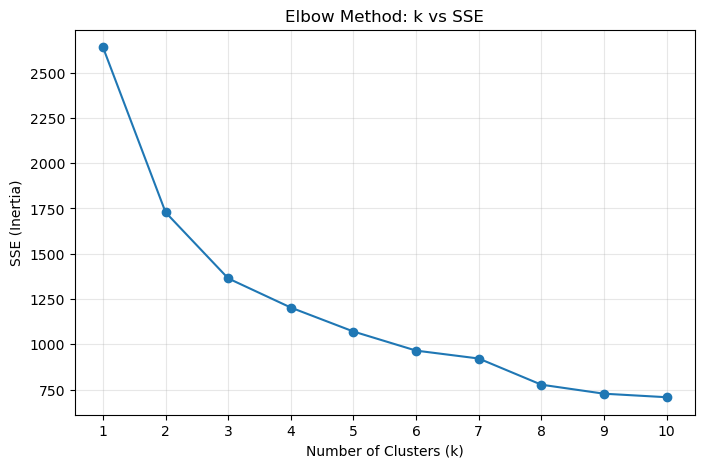

In [59]:
# 4. Elbow Method
sse_values = []
for k in range(1,11):
    km=KMeans(n_clusters=k, n_init="auto", random_state=42)
    km.fit(scaled_x)
    sse_values.append(km.inertia_)
    print(f"k={k} → SSE={km.inertia_:.2f}")

plt.figure(figsize=(8,5))
plt.plot(range(1,11), sse_values, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("SSE (Inertia)")
plt.title("Elbow Method: k vs SSE")
plt.xticks(range(1,11))
plt.grid(True, alpha=0.3)
plt.show()

In [60]:
# 5. Train K-Means (Reproduce Lesson)
kmeans=KMeans(n_clusters=K, n_init="auto", random_state=42)
targets=kmeans.fit_predict(scaled_x)
df["Clusters"]=targets.astype(int)
print("Data Frame with Clusters:\n",df.head(5))

Data Frame with Clusters:
    Channel  Region    Fresh    Milk  Grocery  Frozen  Detergents_Paper  \
0        2       3  12669.0  9656.0   7561.0   214.0            2674.0   
1        2       3   7057.0  9810.0   9568.0  1762.0            3293.0   
2        2       3   6353.0  8808.0   7684.0  2405.0            3516.0   
3        1       3  13265.0  1196.0   4221.0  6404.0             507.0   
4        2       3  22615.0  5410.0   7198.0  3915.0            1777.0   

   Delicassen  Clusters  
0     1338.00         0  
1     1776.00         0  
2     3938.25         0  
3     1788.00         3  
4     3938.25         3  


In [61]:
# 6. Evaluate K-Means
sil=silhouette_score(scaled_x, targets)
dbi=davies_bouldin_score(scaled_x, targets)
print("Metrics:\n")
print(f"Silhouette Score : {sil:.3f} (closer to +1 is better)")
print(f"Davies–Bouldin   : {dbi:.3f} (lower is better)")

Metrics:

Silhouette Score : 0.283 (closer to +1 is better)
Davies–Bouldin   : 1.270 (lower is better)


In [62]:
# 7. Research & Train a Second Clustering Algorithm
agg = AgglomerativeClustering(n_clusters=5, linkage="ward")
agg_labels = agg.fit_predict(scaled_x)

df["Cluster_AGG"] = agg_labels.astype(int)

agg_sil = silhouette_score(scaled_x, agg_labels)
agg_dbi = davies_bouldin_score(scaled_x, agg_labels)

print("Agglomerative Clustering Metrics:\n")
print(f"Silhouette Score : {agg_sil:.3f}  (closer to +1 is better)")
print(f"Davies-Bouldin   : {agg_dbi:.3f}  (lower is better)")

print("\nAgglomerative Cluster Sizes:")
print(df["Cluster_AGG"].value_counts().sort_index())

Agglomerative Clustering Metrics:

Silhouette Score : 0.218  (closer to +1 is better)
Davies-Bouldin   : 1.325  (lower is better)

Agglomerative Cluster Sizes:
Cluster_AGG
0     70
1     72
2    164
3     55
4     79
Name: count, dtype: int64


In [63]:
# 8. Compare Methods
print("\nAlgorithm Comparison:")
print(f"{'Algorithm':<25} {'Silhouette':>12} {'Davies-Bouldin':>16}")
print(f"{'K-Means (k=5)':<25} {sil:>12.3f} {dbi:>16.3f}")
print(f"{'Agglomerative (k=5)':<25} {agg_sil:>12.3f} {agg_dbi:>16.3f}")


Algorithm Comparison:
Algorithm                   Silhouette   Davies-Bouldin
K-Means (k=5)                    0.283            1.270
Agglomerative (k=5)              0.218            1.325


In [64]:
# 9. Sanity Check
print("\nSanity Check (first 3 customers):")
print(df.loc[[0,1,2], ["Clusters", "Cluster_AGG"]])


Sanity Check (first 3 customers):
   Clusters  Cluster_AGG
0         0            4
1         0            4
2         0            0


In [65]:
# 10. Save Output
OUT_PATH=r"D:\Downloads\DS-ML COURSE\Jupiter(DS-ML)\segmented_wholesale_customers.csv"
df.to_csv(OUT_PATH, index=False)
print("Saved!\n")

Saved!



In [66]:
## Second Clustering Algorithm — Agglomerative (Hierarchical) Clustering
"""
I chose `AgglomerativeClustering` as the second algorithm for the following
reasons specific to this dataset:

**Why it fits wholesale customer segmentation:**
- K-Means assumes clusters are roughly spherical and equal in size.
  Wholesale spending data is heavily skewed (Delicassen skewness ≈ 11,
  Fresh ≈ 2.6) — customer segments are unlikely to be perfectly spherical,
  making a hierarchy-based approach more flexible.
- Agglomerative clustering uses `linkage` to merge clusters based on
  inter-cluster distances rather than centroid positions, so it handles
  elongated or irregular cluster shapes that K-Means can struggle with.
- It produces a **dendrogram** (tree of merges) that makes it possible to
  inspect the natural hierarchy of customer types — for example, whether
  "high-fresh" customers naturally split further into restaurant vs.
  food-retailer sub-segments.
- Using the same `n_clusters=5` as K-Means lets us compare the two
  algorithms directly on the same number of segments.

**Source:** scikit-learn documentation —
[AgglomerativeClustering](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AgglomerativeClustering.html)

"""

'\nI chose `AgglomerativeClustering` as the second algorithm for the following\nreasons specific to this dataset:\n\n**Why it fits wholesale customer segmentation:**\n- K-Means assumes clusters are roughly spherical and equal in size.\n  Wholesale spending data is heavily skewed (Delicassen skewness ≈ 11,\n  Fresh ≈ 2.6) — customer segments are unlikely to be perfectly spherical,\n  making a hierarchy-based approach more flexible.\n- Agglomerative clustering uses `linkage` to merge clusters based on\n  inter-cluster distances rather than centroid positions, so it handles\n  elongated or irregular cluster shapes that K-Means can struggle with.\n- It produces a **dendrogram** (tree of merges) that makes it possible to\n  inspect the natural hierarchy of customer types — for example, whether\n  "high-fresh" customers naturally split further into restaurant vs.\n  food-retailer sub-segments.\n- Using the same `n_clusters=5` as K-Means lets us compare the two\n  algorithms directly on the s